## Low regret strategies for the use of biomass in the European energy transition
### Master's Thesis Oliver Keller 2024

### Preparation
Use the julia code which can be found under https://github.com/oliver-keller/EuSysMod to create the scenarios you want and run the optimization model. The outputsOfInterest.csv file contains the different usage categories in the different columns and the iterations in the rows. This file must be copied into the DECIDE/data directory to run this script.


Now import all the needed libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist, euclidean
from tabulate import tabulate
import os

from utilities.produce_interpretable_tree import produce_interpretable_tree

Next we read in the data and specify/create an output directory

In [2]:
# df_input = pd.read_csv("data/outputsOfInterest.csv", sep=",") # Read the CSV file
df_input = pd.read_csv(r"data\merged_outputsOfInterest.csv", sep=",") # Read the CSV file
df_input = df_input.drop(columns=['iteration']) # Drop the iteration column
df_input= df_input.abs() # Take the absolute value of all columns

folder = "./figures/"
if not os.path.exists(folder): # Create the folder if it does not exist
   os.makedirs(folder)

## combine categories
df_input['LTH'] = df_input['LTH'] + df_input['DH'] + df_input['SpaceHeating'] # Combine 'LTH', 'DH', and 'SpaceHeating' columns
df_input = df_input.drop(columns=['DH', 'SpaceHeating']) # Drop the original 'DH' and 'SpaceHeating' columns
df_input['HTH'] = df_input['MTH'] + df_input['HTH'] # Combine 'MTH' and 'HTH' 
df_input = df_input.drop(columns=['MTH']) # Drop the original 'DH' and 'SpaceHeating' columns




df_input

,crudeOil,HVC,CHP,LTH,HTH,rawBiogas,syngas,coal
0,763.747731,0.778222,0.000035,0.000033,0.000042,0.000602,0.000000,0.000082
1,312.248961,476.997861,0.000000,0.000025,0.000000,0.000236,0.000000,0.000000
2,44.538034,0.000385,0.000291,0.001467,82.622310,23.287683,0.000333,0.000597
3,133.512980,0.000083,0.000000,0.000302,2.828780,1.062046,0.000000,0.000103
4,815.671824,1.970035,0.000000,0.000000,0.000000,0.000113,0.000000,0.000000
...,...,...,...,...,...,...,...,...
995,424.839873,578.415636,0.000000,0.000011,0.000000,0.000137,0.000000,0.000000
996,756.747318,41.686315,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
997,814.368812,187.175222,0.000000,0.000000,0.000000,0.000078,0.000000,0.000000
998,783.039065,233.621143,0.000045,0.000068,0.802602,0.000519,0.000000,0.000208


Now we create a visualization of the data in a table showing the maximum and minimum of each category. 
Next the categories with low biomass usage (below 10% of highest max value) are filtered out and a spiderplot is created showing the biomass usage of the relevant categories.

In [3]:
## Create a taple with the max and min values of each column
# Calculate the max and min values for each column
data_max = df_input.max().values
data_min = df_input.min().values

# Create a list of lists with column name, max value, and min value
table_data = []
for column in df_input.columns:
    max_value = df_input[column].max()
    min_value = df_input[column].min()
    table_data.append([column, max_value, min_value])

# Print the table
print(tabulate(table_data, headers=["Column Name", "Max Value", "Min Value"], tablefmt="grid"))

+---------------+---------------+-------------+
| Column Name   |     Max Value |   Min Value |
+===============+===============+=============+
| crudeOil      | 978.745       |     1.77331 |
+---------------+---------------+-------------+
| HVC           | 621.491       |     0       |
+---------------+---------------+-------------+
| CHP           |   0.00102235  |     0       |
+---------------+---------------+-------------+
| LTH           | 260.589       |     0       |
+---------------+---------------+-------------+
| HTH           | 612.102       |     0       |
+---------------+---------------+-------------+
| rawBiogas     | 111.272       |     0       |
+---------------+---------------+-------------+
| syngas        |   0.000468281 |     0       |
+---------------+---------------+-------------+
| coal          |  76.4971      |     0       |
+---------------+---------------+-------------+


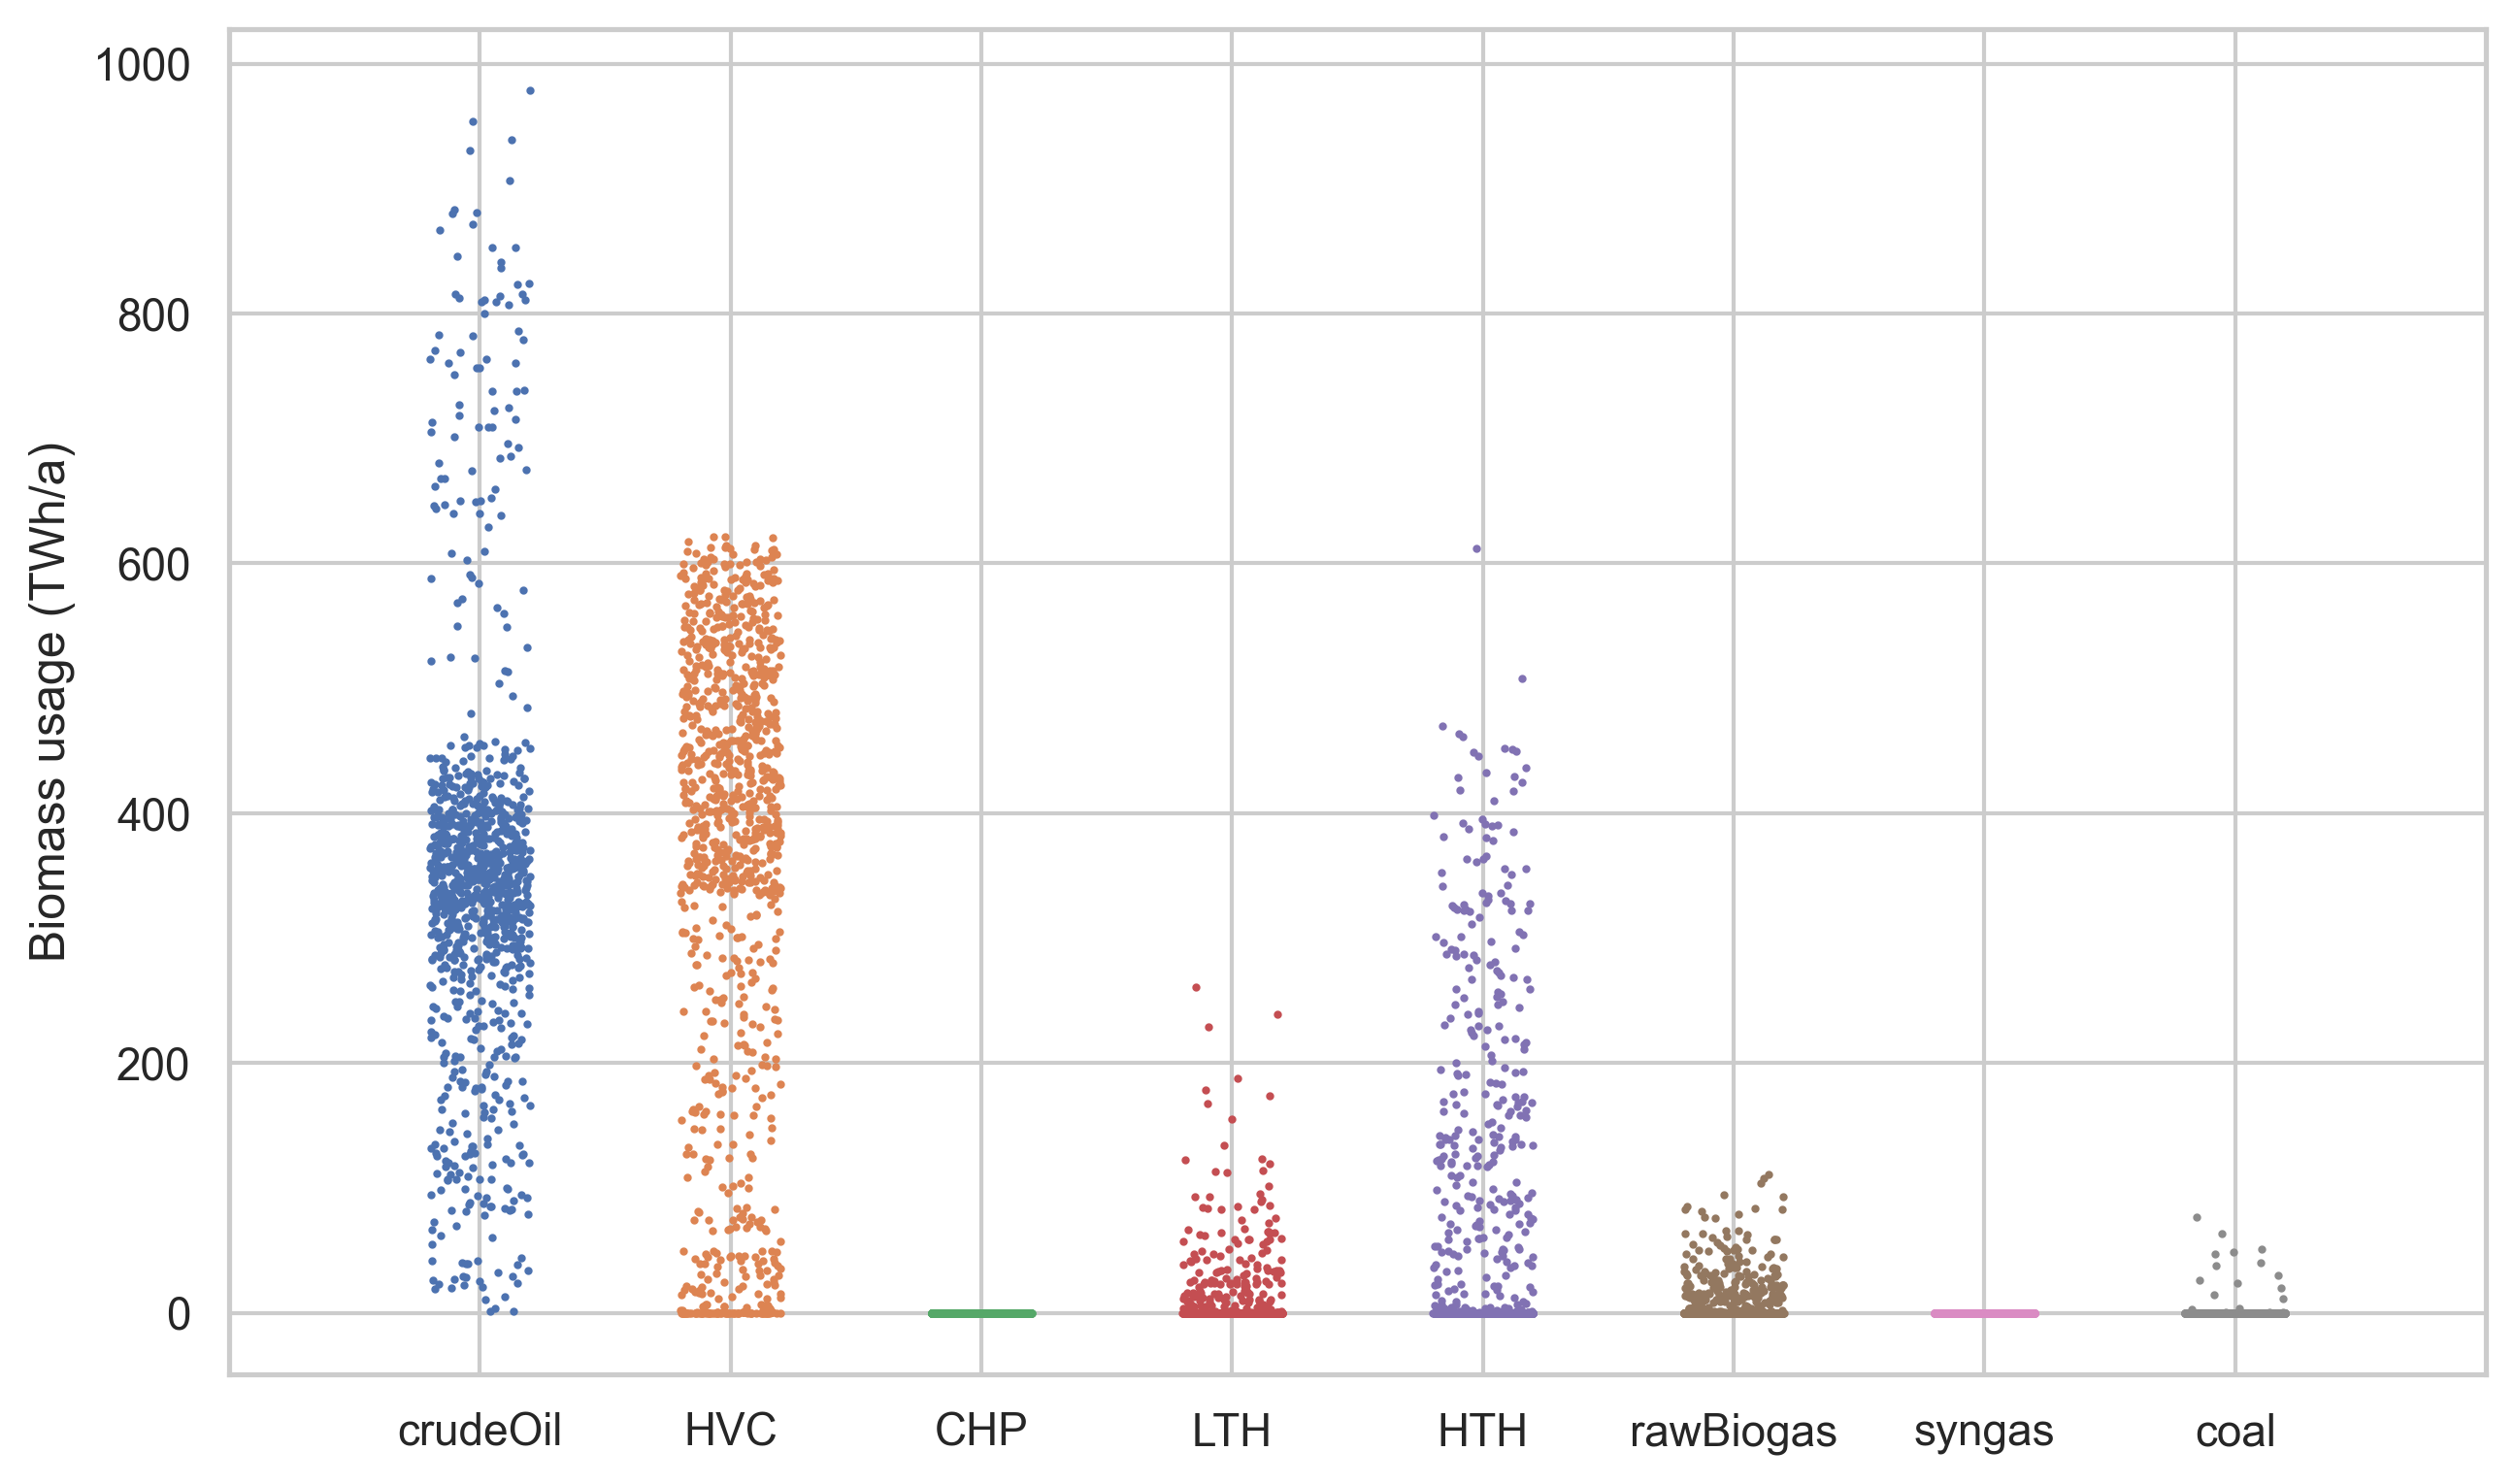

In [4]:

# Plot the dataframe
plt.figure(figsize=(10, 6), dpi=300)
for i, category in enumerate(df_input.columns):
    plt.scatter([i-0.2]*len(df_input)+np.random.random(len(df_input),)*0.4, df_input[category].abs(), s=1, )

# Set the x-axis tick labels
plt.xticks(range(len(df_input.columns)), df_input.columns, rotation=0)
plt.xlim(-1, len(df_input.columns))

# Set labels
plt.ylabel('Biomass usage (TWh/a)')

# Show the plot
plt.show()

In [5]:
## Filter not relevant columns
# Filter the columns with higher max_value than 10% of the highest max_value
highest_max_value = max(data_max)
filtered_columns = [column for column, max_value, _ in table_data if max_value > 0.05 * highest_max_value]

# Remove the columns with too low values
df_filtered = df_input[filtered_columns]

Define the dimesnions shown in the plots:

In [6]:
DIMENSIONS = ['crudeOil', 'HVC', 'LTH', 'HTH', 'Biogas', 'Coal']

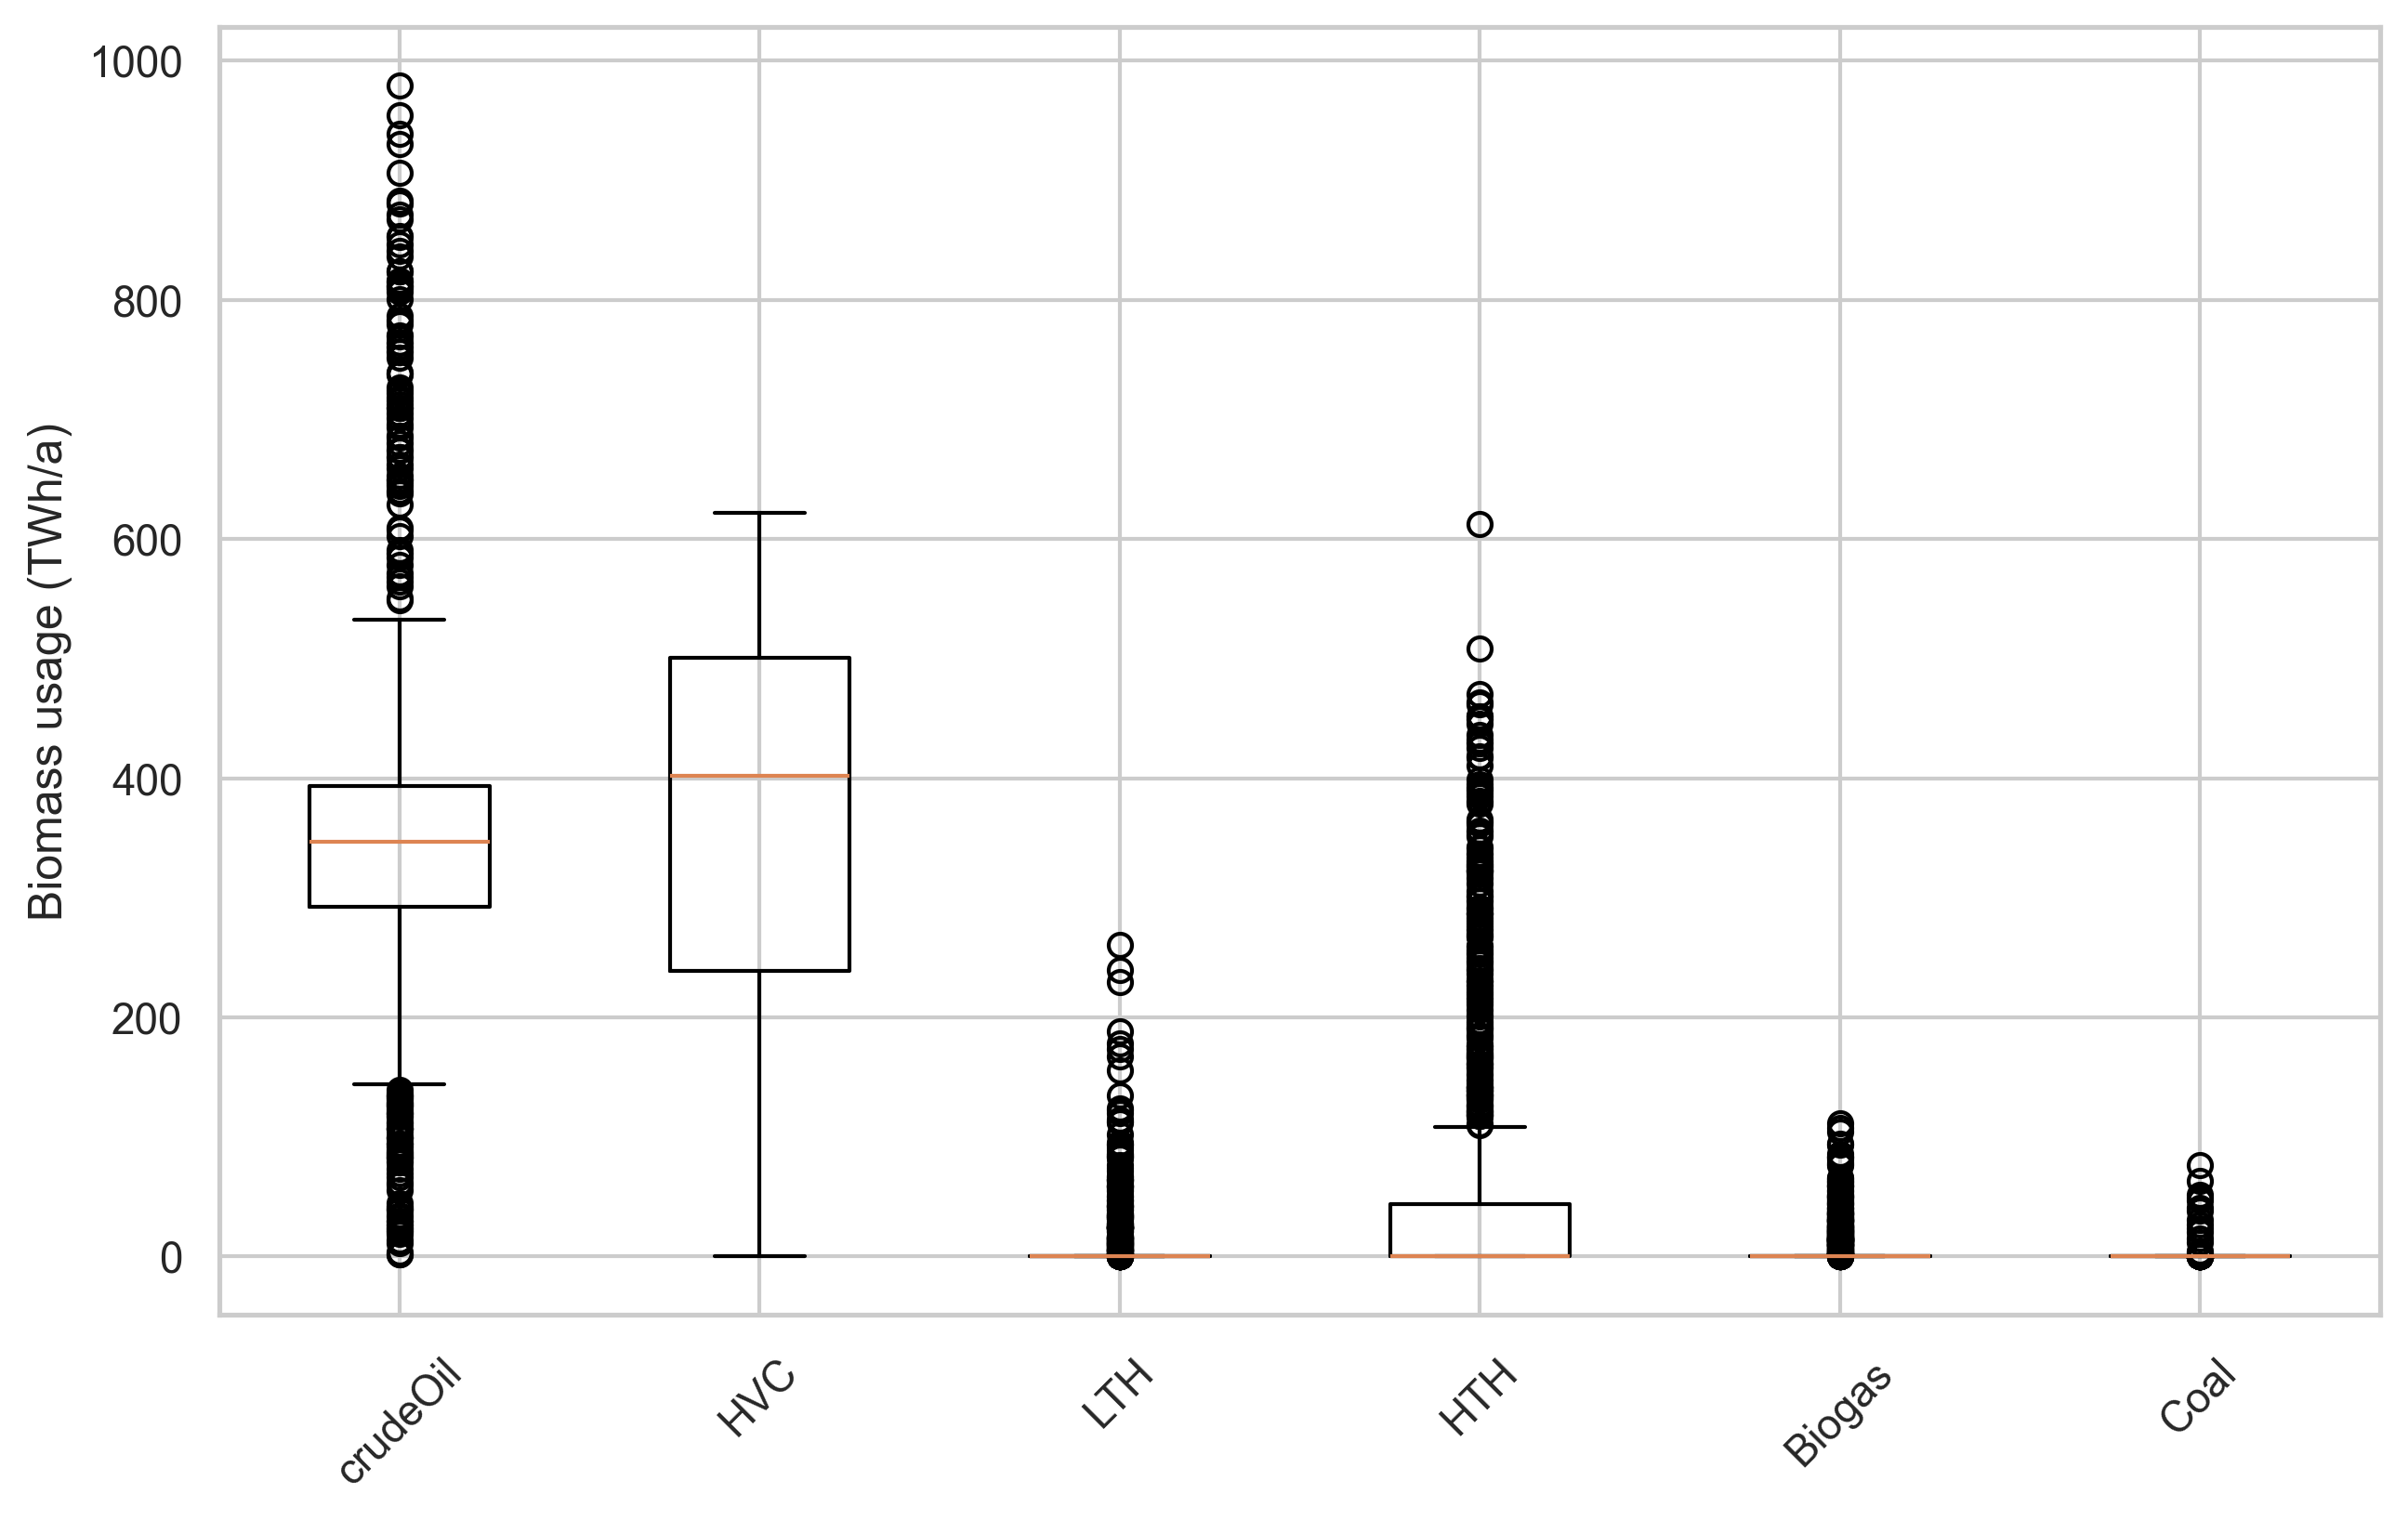

In [7]:
# Create a boxplot
plt.figure(figsize=(10, 6), dpi=300)
plt.boxplot(df_filtered.values)
# The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers.

# Set the x-axis tick labels
plt.xticks(range(1, len(df_filtered.columns) + 1), DIMENSIONS, rotation=45)

# Set the y-axis label
plt.ylabel('Biomass usage (TWh/a)')

plt.show()

If you want to normalize the data before the clustering this can be dine with the next cell. I recommend not normalizing the values because it stretches the space and the clusering algorithm does not see the real distances between the scenarios.

In [8]:
"""
# Normalize each column
for column in df_filtered.columns:
    max_value = df_filtered[column].max()
    df_filtered[column] = df_filtered[column] / max_value
"""

'\n# Normalize each column\nfor column in df_filtered.columns:\n    max_value = df_filtered[column].max()\n    df_filtered[column] = df_filtered[column] / max_value\n'

In [9]:
# Print and save the filtered dataframe which will be used as input for the clustering
print(df_filtered)
# df_filtered.to_csv(folder+"df_filtered.csv",sep=";", index=False)

       crudeOil         HVC       LTH         HTH  rawBiogas      coal
0    763.747731    0.778222  0.000033    0.000042   0.000602  0.000082
1    312.248961  476.997861  0.000025    0.000000   0.000236  0.000000
2     44.538034    0.000385  0.001467   82.622310  23.287683  0.000597
3    133.512980    0.000083  0.000302    2.828780   1.062046  0.000103
4    815.671824    1.970035  0.000000    0.000000   0.000113  0.000000
..          ...         ...       ...         ...        ...       ...
995  424.839873  578.415636  0.000011    0.000000   0.000137  0.000000
996  756.747318   41.686315  0.000000    0.000000   0.000000  0.000000
997  814.368812  187.175222  0.000000    0.000000   0.000078  0.000000
998  783.039065  233.621143  0.000068    0.802602   0.000519  0.000208
999  202.169691  234.861735  0.000130  195.066364   0.004980  0.000095

[1000 rows x 6 columns]


# Clustering

Define main parameter

In [10]:
NUMBER_OF_CLUSTERS = 3

Calculate the decision tree and save the dataframe with the cluster column added

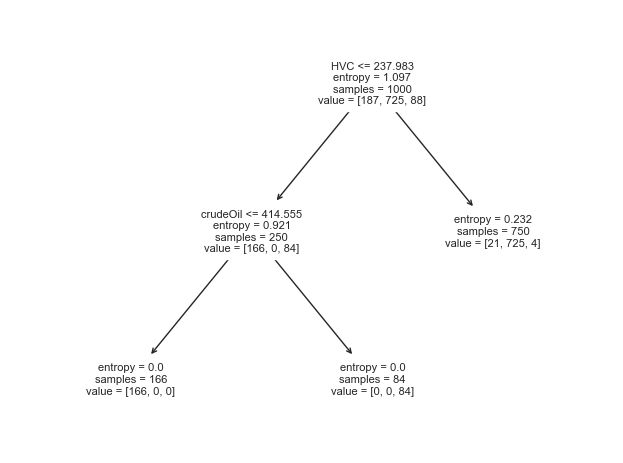

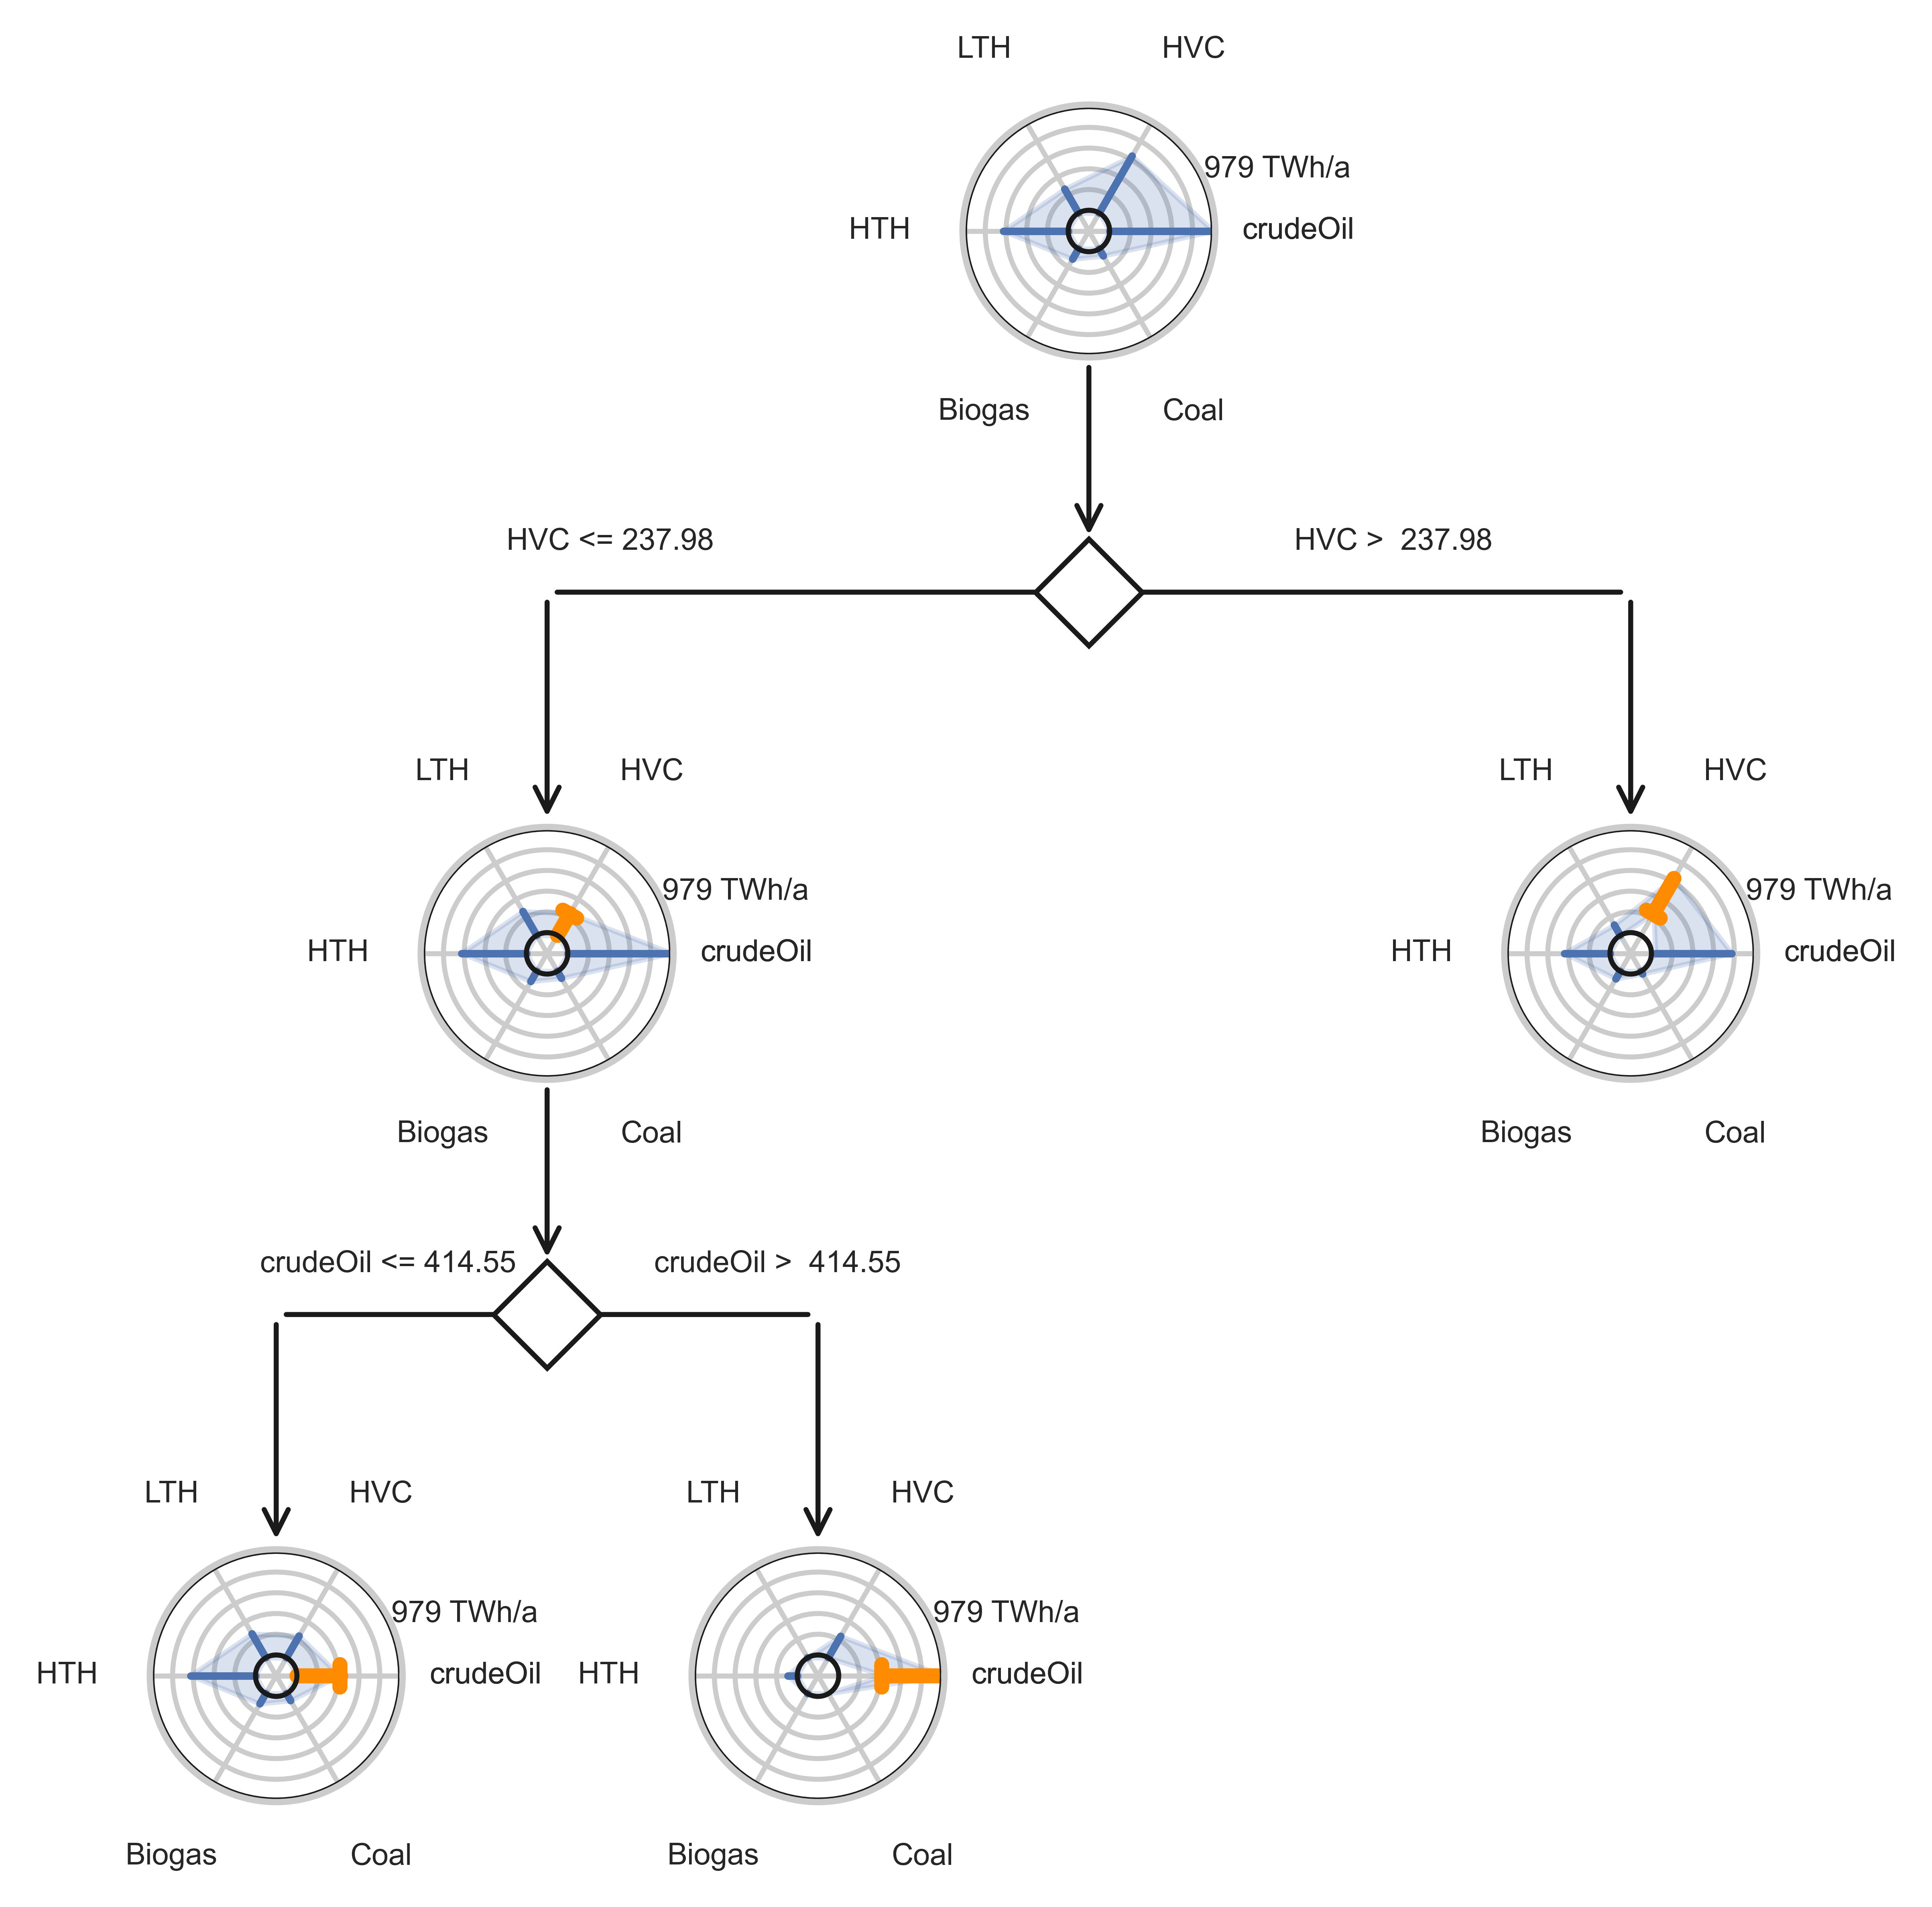

In [11]:

df_filtered_with_cluster, nodes, choices, decision_space = produce_interpretable_tree(df_filtered, DIMENSIONS, NUMBER_OF_CLUSTERS, plot_all_spyders=False, figure_folder=folder, tree_size=(6, 6), absolute_values=True, colors=['darkorange', 'darkorange', 'darkorange'], print_info=False)



Print the choices needed to do the regret calculation in EuSysMod

In [12]:
print(choices)

{0: [' HVC <= 237.98', ' HVC >  237.98'], 1: [' crudeOil <= 414.55', ' crudeOil >  414.55']}


Calculate the geometric median of each cluster

In [13]:
median_data = [] # List to store the results
dimensions = [dim for dim in list(df_filtered_with_cluster.columns) if "cluster" not in dim] # Extract the dimensions from the DataFrame

for cluster in range(NUMBER_OF_CLUSTERS):
    df_cluster = df_filtered_with_cluster[df_filtered_with_cluster['cluster_final'] == cluster] # Extract the points of the cluster

    # Extract the points from the DataFrame
    points = df_cluster[dimensions].values

    # Calculate the pairwise distances between the points
    distances = cdist(points, points, metric='euclidean')

    # Calculate the sum of distances for each point
    sum_distances = np.sum(distances, axis=1)

    # Find the index of the point with the minimum sum of distances
    geometric_median_index = np.argmin(sum_distances)

    # Get the geometric median_df point
    geometric_median = points[geometric_median_index]

    # Find the index of the geometric median point in the original DataFrame
    index = np.where((df_filtered_with_cluster[dimensions[0]] == geometric_median[0]) & (df_filtered_with_cluster[dimensions[1]] == geometric_median[1]) & (df_filtered_with_cluster[dimensions[2]] == geometric_median[2]))[0][0] +1

    # Append the result to the median_data list
    median_data.append([cluster, index] + list(geometric_median))

# Create a DataFrame from the median_data list
column_names = ['cluster', 'index'] + dimensions
median_df = pd.DataFrame(median_data, columns=column_names)


print(median_df)


   cluster  index    crudeOil         HVC        LTH         HTH  rawBiogas  \
0        0    164  161.052074   43.493235  39.696257  244.830713  24.566363   
1        1    338  357.402460  450.842678   0.000013    0.000000   0.000201   
2        2    800  738.172570   43.272623   0.000000    0.000000   0.000120   

       coal  
0  0.000183  
1  0.000000  
2  0.000000  


# Plot the results

### Create a 3D scatter plot
That only makes sence if the filtered data contains at least 3 dimension -> choose most important dimensions

In [14]:

STRATEGY_NAMES = {1: 'Strategy HVC+', 2: 'Strategy HVC- oil+', 0: 'Strategy HVC- oil-'}
COLOR_MAP = {1: 'blue', 2: 'darkviolet', 0: 'darkgreen'}

# Map the 'cluster_final' column to the defined colors
COLORS = df_filtered_with_cluster['cluster_final'].map(COLOR_MAP)

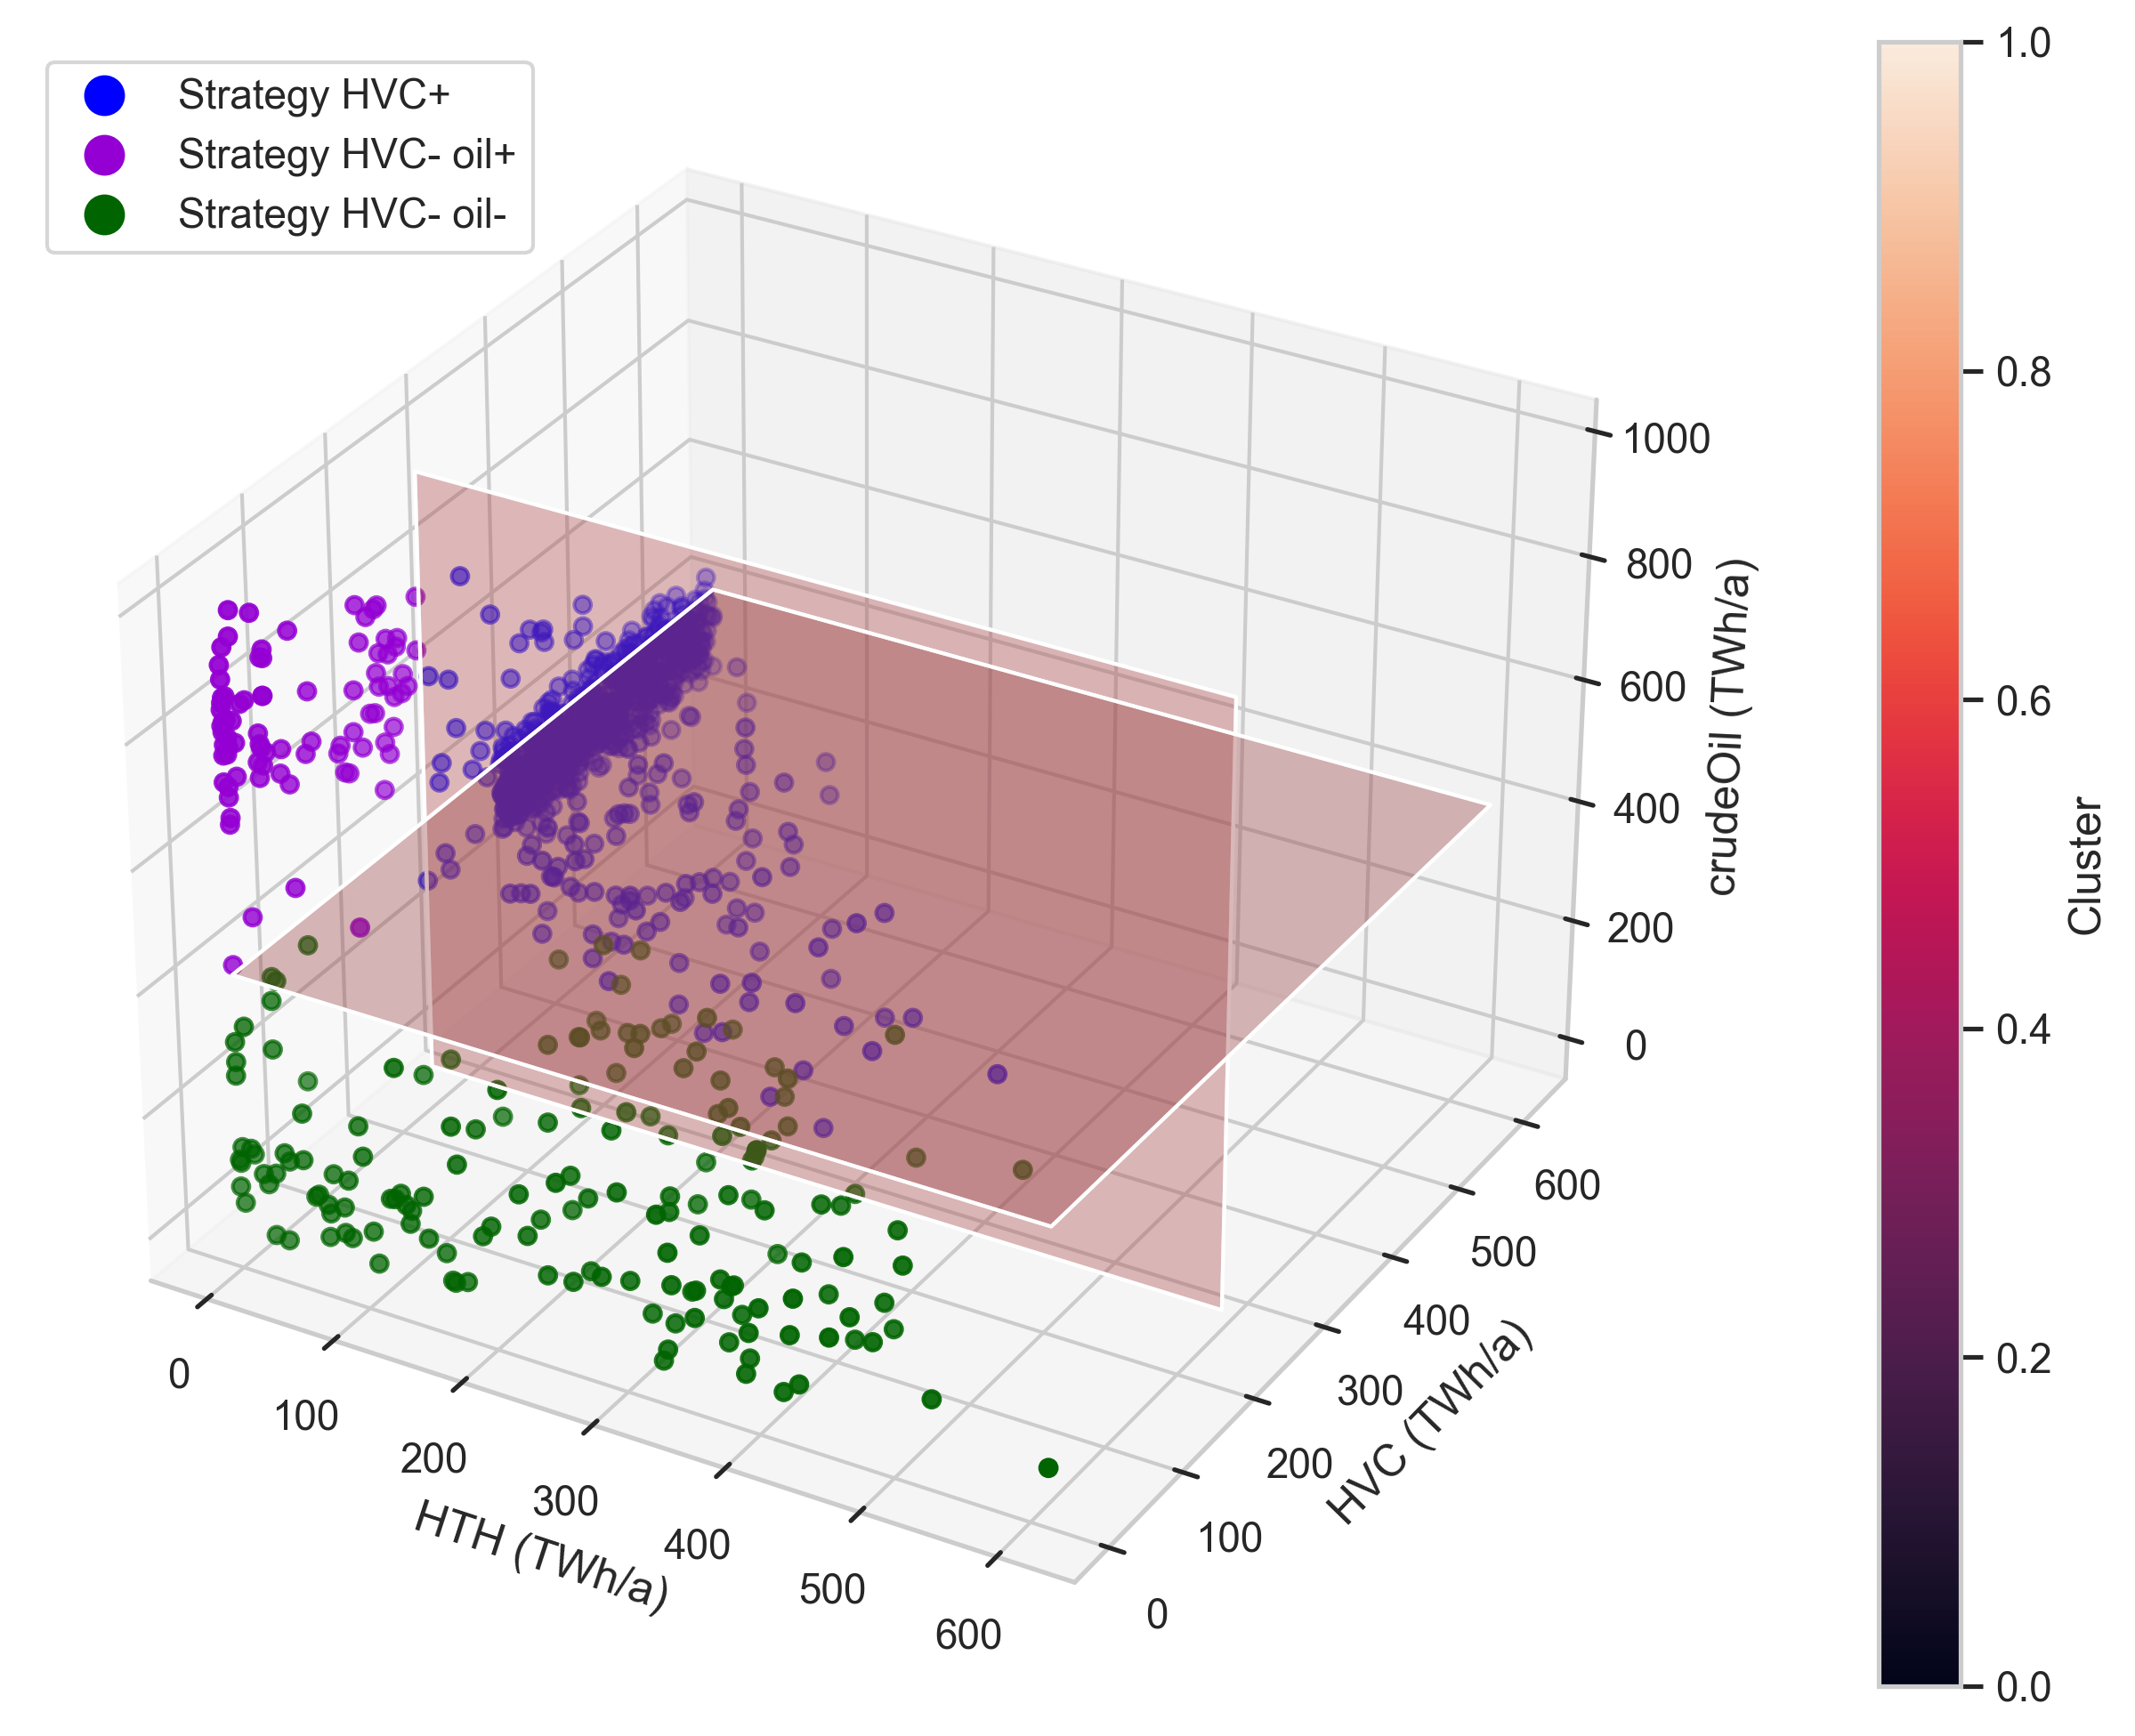

In [15]:
X_AXIS = 'HTH'
Y_AXIS = 'HVC'
Z_AXIS = 'crudeOil'

# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Plot the dots
dots = ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], df_filtered_with_cluster[Z_AXIS], c=COLORS, zorder = 1)


# Define funcitons to plot the planes in the 3D space to show the decision tree splits
def plot_x_plane(ax, x_value, color='r', alpha=0.5):
    yy, zz = np.meshgrid(
        np.linspace(df_filtered_with_cluster[Y_AXIS].min(), df_filtered_with_cluster[Y_AXIS].max(), 10),
        np.linspace(df_filtered_with_cluster[Z_AXIS].min(), df_filtered_with_cluster[Z_AXIS].max(), 10)
    )
    xx = np.full(yy.shape, x_value)
    ax.plot_surface(xx, yy, zz, color=color, alpha=alpha, rstride=100, cstride=100)

def plot_y_plane(ax, y_value, color='r', alpha=0.5):
    xx, zz = np.meshgrid(
        np.linspace(df_filtered_with_cluster[X_AXIS].min(), df_filtered_with_cluster[X_AXIS].max(), 10),
        np.linspace(df_filtered_with_cluster[Z_AXIS].min(), df_filtered_with_cluster[Z_AXIS].max(), 10)
    )
    yy = np.full(xx.shape, y_value)
    ax.plot_surface(xx, yy, zz, color=color, alpha=alpha, rstride=100, cstride=100)

def plot_z_plane(ax, z_value, color='r', alpha=0.5):
    xx, yy = np.meshgrid(
        np.linspace(df_filtered_with_cluster[X_AXIS].min(), df_filtered_with_cluster[X_AXIS].max(), 10),
        np.linspace(df_filtered_with_cluster[Y_AXIS].min(), df_filtered_with_cluster[Y_AXIS].max(), 10)
    )
    zz = np.full(xx.shape, z_value)
    ax.plot_surface(xx, yy, zz, color=color, alpha=alpha, rstride=100, cstride=100)
    
# Plot the decision tree split as planes
for cluster, choice in choices.items():
    for condition in choice:
        column, operator, value = condition.split()
        if column == X_AXIS:
            plot_x_plane(ax, x_value=float(value), color='r', alpha=0.2)
        elif column == Y_AXIS:
            plot_y_plane(ax, y_value=float(value), color='r', alpha=0.2)
        elif column == Z_AXIS:
            plot_z_plane(ax, z_value=float(value), color='r', alpha=0.2)


# Set labels and title
ax.set_xlabel(X_AXIS+' (TWh/a)')
ax.set_ylabel(Y_AXIS+' (TWh/a)')
ax.set_zlabel(Z_AXIS+' (TWh/a)')


# Add a colorbar
plt.colorbar(dots, ax=ax, label='Cluster') # just that the image is not cropped


# Create custom legend handles
handles = [
    mlines.Line2D([], [], color=COLOR_MAP[1], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[1]),
    mlines.Line2D([], [], color=COLOR_MAP[2], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[2]),
    mlines.Line2D([], [], color=COLOR_MAP[0], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[0]),
]

# Add the legend
ax.legend(handles=handles, loc='upper left')

# plt.savefig("results/3D-tree.svg",  format="svg")
# plt.savefig("results/3D-tree.pdf")

# Show the plot
plt.show()




## Create 2D cuts 

Define function

In [16]:
## Create a 2D side view plot
def create_2D_side_view_plot(df_filtered_with_cluster, median_df, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS, limits=False):
    fig = plt.figure(figsize=(7, 7), dpi=300)
    ax = fig.add_subplot(111)

    # Plot the side view (2D)
    dots = ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], c=COLORS, alpha=0.6)
    dots= ax.scatter(df_filtered_with_cluster[X_AXIS], df_filtered_with_cluster[Y_AXIS], c='black', alpha=0.1)
    if type(median_df) == pd.DataFrame: median_df = ax.scatter(median_df[X_AXIS], median_df[Y_AXIS], c = 'red', alpha=0.9)

    # Plot the planes on the 2D side view
    for i, choice in choices.items():
        for condition in choice:
            column, operator, value = condition.split()
            value = float(value)
            if column == X_AXIS:
                ax.axvline(x=value, color='r', linestyle='--', alpha=0.5)
            elif column == Y_AXIS:
                ax.axhline(y=value, color='r', linestyle='--', alpha=0.5)
      

    # Set labels and title for the 2D plot
    ax.set_xlabel(X_AXIS + ' (TWh/a)')
    ax.set_ylabel(Y_AXIS + ' (TWh/a)')


    # Create custom legend handles
    if type(median_df) != type(None):
        handles = [
            mlines.Line2D([], [], color=COLOR_MAP[1], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[1]),
            mlines.Line2D([], [], color=COLOR_MAP[2], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[2]),
            mlines.Line2D([], [], color=COLOR_MAP[0], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[0]),
            mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Geometric Median')
        ]
    else:
          handles = [
            mlines.Line2D([], [], color=COLOR_MAP[1], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[1]),
            mlines.Line2D([], [], color=COLOR_MAP[2], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[2]),
            mlines.Line2D([], [], color=COLOR_MAP[0], marker='o', linestyle='None', markersize=10, label=STRATEGY_NAMES[0]),
        ]

    # Add the legend
    ax.legend(handles=handles, loc='upper right')

    # define range of the plot
    if limits:
        ax.set_xlim(-30, 650)
        ax.set_ylim(-50, 1030)


    # plt.savefig(f"results/2D-tree_{X_AXIS}_{Y_AXIS}.svg",  format="svg")
    # plt.savefig(f"results/2D-tree_{X_AXIS}_{Y_AXIS}.pdf")

    # Show the plots
    plt.show()


Create 2D plots

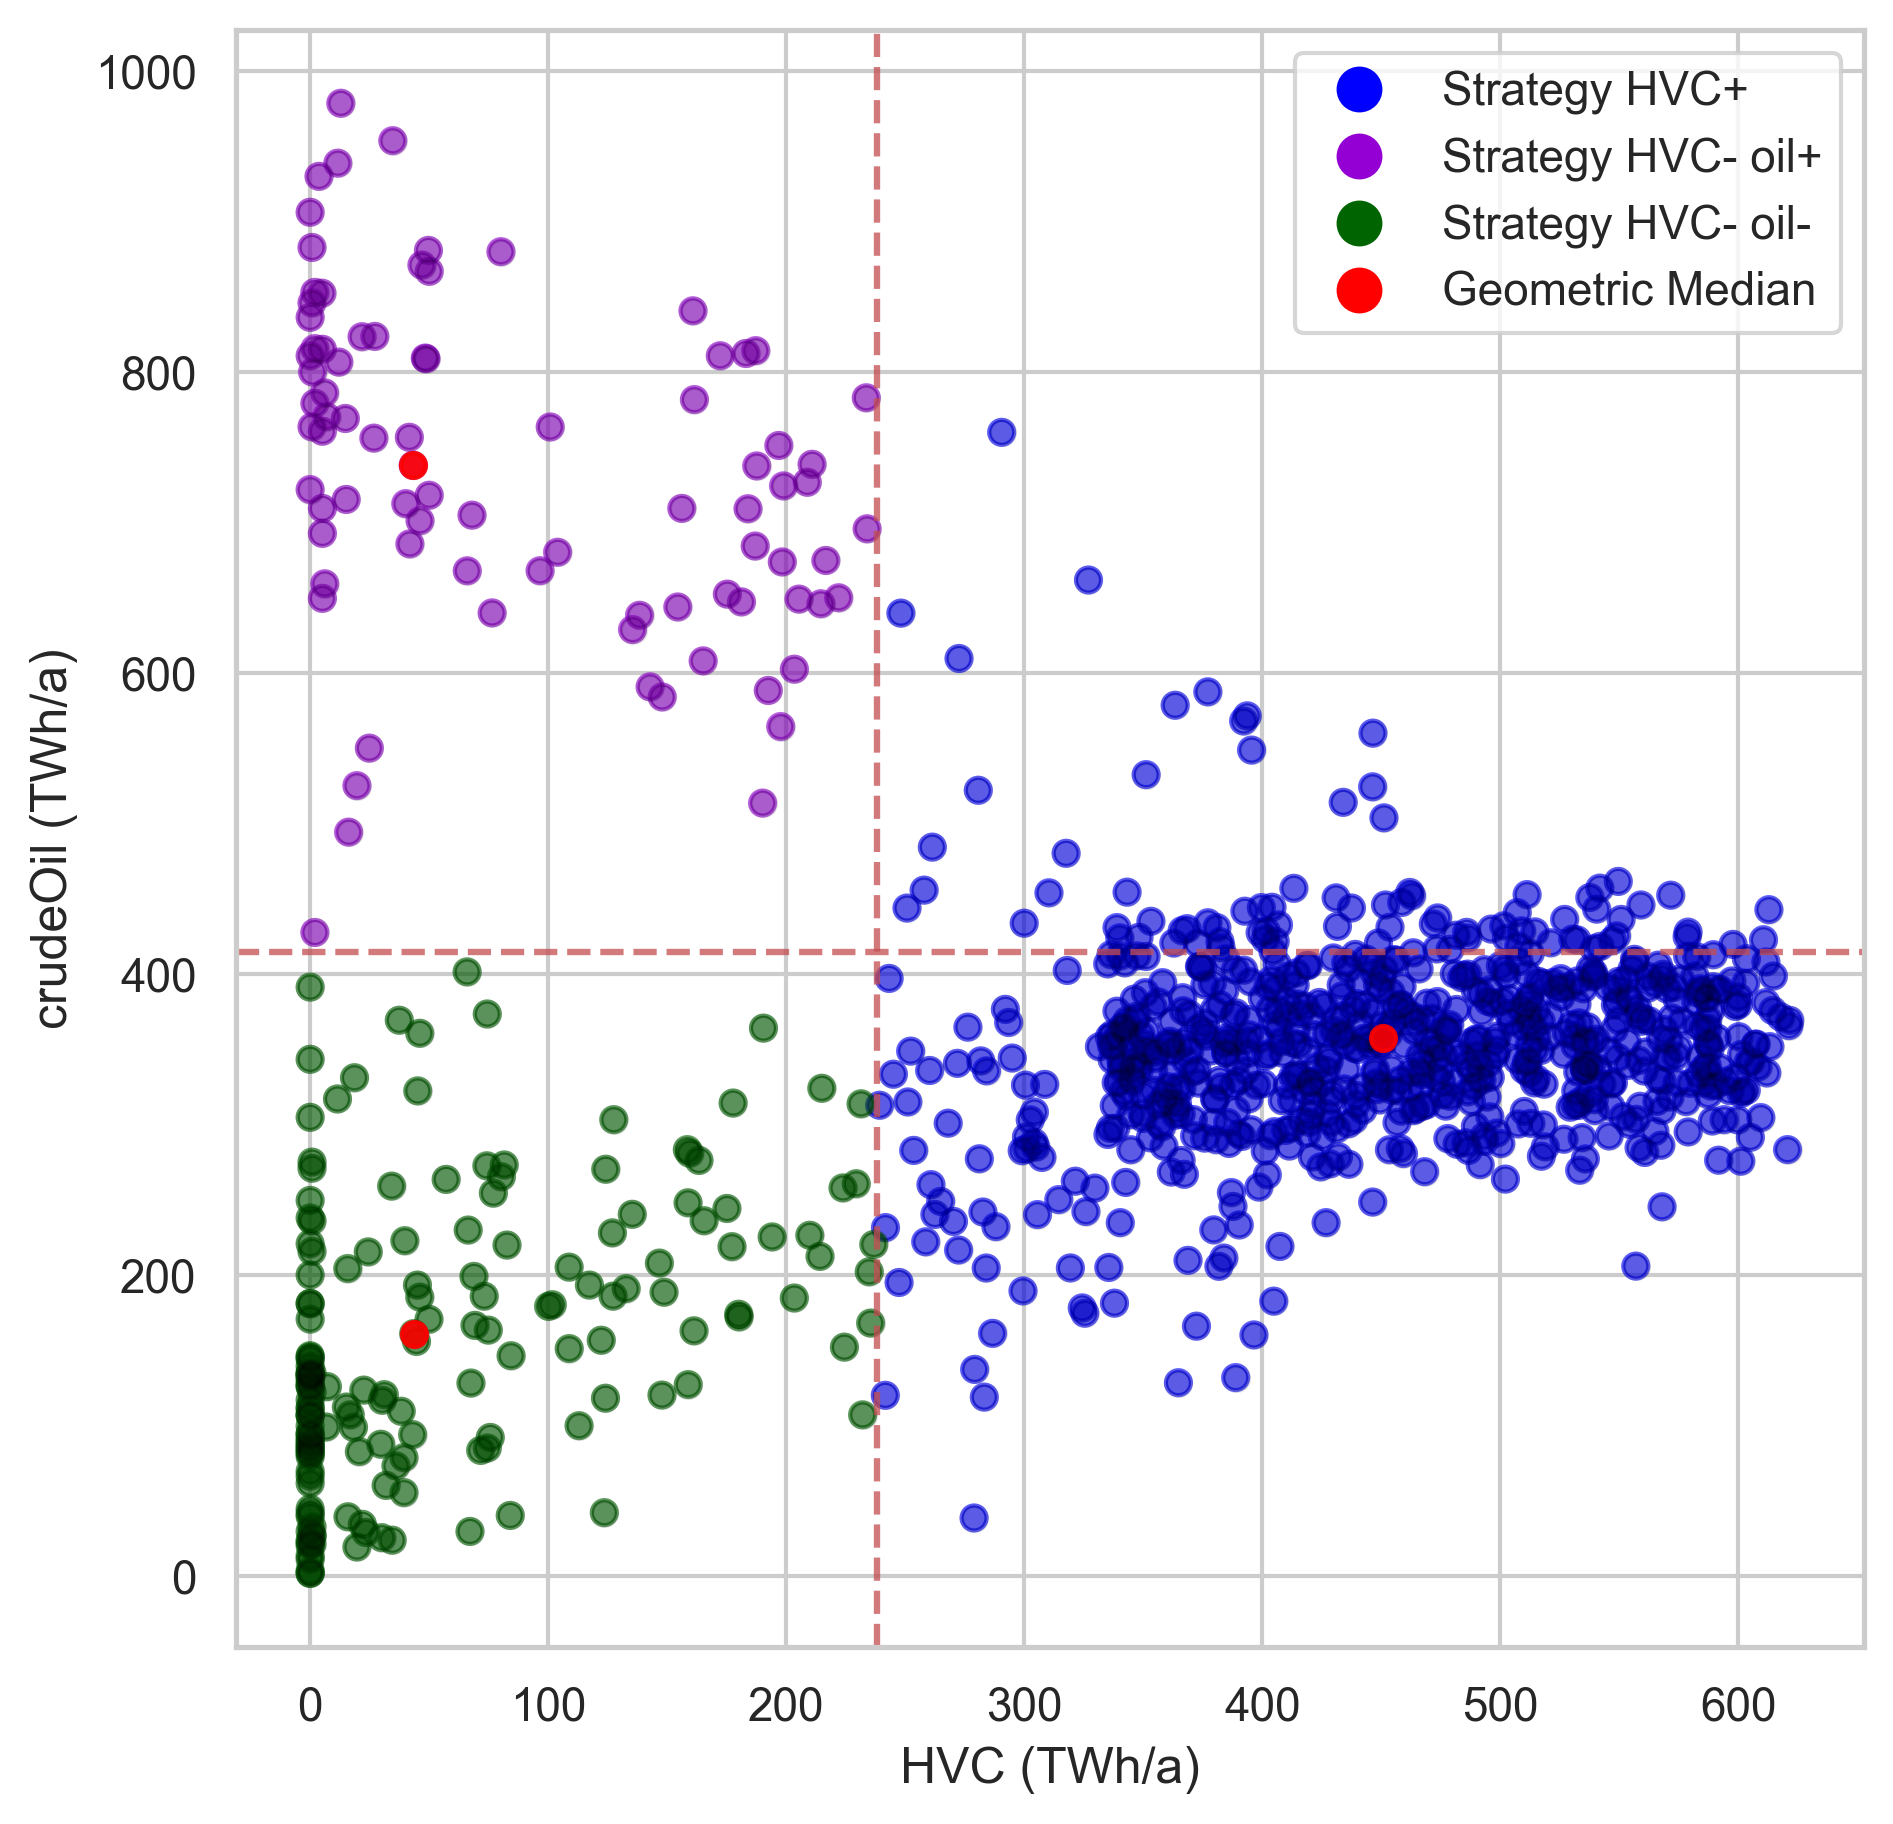

In [17]:
# Specify cut plane
X_AXIS = 'HVC'
Y_AXIS = 'crudeOil'

create_2D_side_view_plot(df_filtered_with_cluster, median_df, STRATEGY_NAMES, COLOR_MAP, COLORS, choices, X_AXIS, Y_AXIS)